In [1]:
# imports
import os
import torch
from torchvision import datasets, transforms
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Generate kaggle api key as json and upload
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
# Download and unzip dataset from kaggle into Colab
!pip install -q kaggle

!kaggle datasets download -d paultimothymooney/kermany2018 -p /content

!unzip -oq /content/kermany2018.zip -d /content

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/kermany2018
License(s): CC-BY-NC-SA-4.0
100% 10.8G/10.8G [00:52<00:00, 222MB/s]



In [5]:
!ls -lb /content
!rm -rf /content/oct2017
!ls -lb /content

total 11371396
drwx------ 5 root root        4096 Apr 10 17:42 drive
-rw-r--r-- 1 root root          67 Apr 10 17:42 kaggle.json
-rw-r--r-- 1 root root 11644282751 Sep 28  2019 kermany2018.zip
drwxr-xr-x 4 root root        4096 Apr 10 17:44 oct2017
drwxr-xr-x 5 root root        4096 Apr 10 17:44 OCT2017\ 
drwxr-xr-x 1 root root        4096 Mar 30 13:34 sample_data
total 11371392
drwx------ 5 root root        4096 Apr 10 17:42 drive
-rw-r--r-- 1 root root          67 Apr 10 17:42 kaggle.json
-rw-r--r-- 1 root root 11644282751 Sep 28  2019 kermany2018.zip
drwxr-xr-x 5 root root        4096 Apr 10 17:44 OCT2017\ 
drwxr-xr-x 1 root root        4096 Mar 30 13:34 sample_data


In [6]:
root = "/content/OCT2017 "

print("=== PATH CHECK ===")
print("Exists:", os.path.exists(root))

if not os.path.exists(root):
    print("❌ Dataset path is wrong")
else:
    print("✅ Dataset path found")

    total_images = 0

    print("\n=== STRUCTURE + COUNTS ===")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(root, split)
        print(f"\n{split.upper()}")

        if not os.path.exists(split_path):
            print(f"❌ Missing folder: {split}")
            continue

        split_total = 0

        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)

            if os.path.isdir(cls_path):
                count = len(os.listdir(cls_path))
                split_total += count
                print(f"{cls}: {count}")

        print(f"Total ({split}): {split_total}")
        total_images += split_total

    print("\n=== GRAND TOTAL ===")
    print(total_images)
    print('expected total = 84484')

=== PATH CHECK ===
Exists: True
✅ Dataset path found

=== STRUCTURE + COUNTS ===

TRAIN
CNV: 37205
DME: 11348
DRUSEN: 8616
NORMAL: 26315
Total (train): 83484

VAL
CNV: 8
DME: 8
DRUSEN: 8
NORMAL: 8
Total (val): 32

TEST
CNV: 242
DME: 242
DRUSEN: 242
NORMAL: 242
Total (test): 968

=== GRAND TOTAL ===
84484
expected total = 84484


In [7]:
transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(
    root=f"{root}/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=f"{root}/val",
    transform=transform
)
test_dataset = datasets.ImageFolder(
    root=f"{root}/test",
    transform=transform
)

In [8]:
import torch.nn as nn

class OCTCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 4))

    def extract_features(self, x):
        x = self.features(x)        # (B, 256, 1, 1)
        x = torch.flatten(x, 1)     # (B, 256)
        return x

    def forward(self, x):
        x = self.features(x)        # (B, 256, 1, 1)
        x = torch.flatten(x, 1)     # (B, 256)
        x = self.classifier(x)      # (B, 4)
        return x


model = OCTCNN(num_classes=4)
print(model)

OCTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [9]:
# Instantiate model on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(device)

cuda


In [10]:
# Scoring function and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# batching
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [ ]:
# can skip once model has trained once and saved parameters
# training loop
#model= model.to(device)
#epochs = 50

#for epoch in range(epochs):
#    running_loss = 0.0

#    for i, data in enumerate(train_loader, 0):
#        inputs, labels = data
#        inputs = inputs.to(device)
#        labels = labels.to(device)

#        optimizer.zero_grad()

#        outputs = model(inputs)
#        loss = criterion(outputs, labels)
#        loss.backward()
#        optimizer.step()
#        running_loss += loss.item()
#        avg_loss = running_loss / (i + 1)
#        if (i+1) % 16 == 0:

#          print(f"epoch [{epoch+1}/{epochs}], Batch [{i+1}], Loss: {avg_loss:.4f}")
print('Training Finished')

# Save after training
#save_dir = "/content/drive/MyDrive/EyeNet/parameters"
#os.makedirs(save_dir, exist_ok=True)

#save_path = f"{save_dir}/oct_cnn_epochs_50.pth"
#torch.save(model.state_dict(), save_path)
#print(f"Model saved to {save_path}")

In [12]:
# load model with trained parameters
from google.colab import files
uploaded = files.upload()

# Get the uploaded filename
file_name = list(uploaded.keys())[0]

# Load model
model.load_state_dict(torch.load(file_name, map_location=device))
model.to(device)
model.eval()

Saving oct_cnn_epochs_50.pth to oct_cnn_epochs_50.pth


OCTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [13]:
# performance on test set
model.eval() # evaluate mode on, must turn off for training

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100*correct / total
print('Test set loss =', avg_test_loss)
print('Test loss =', test_accuracy)

Test set loss = 0.018363412209458356
Test loss = 99.17355371900827


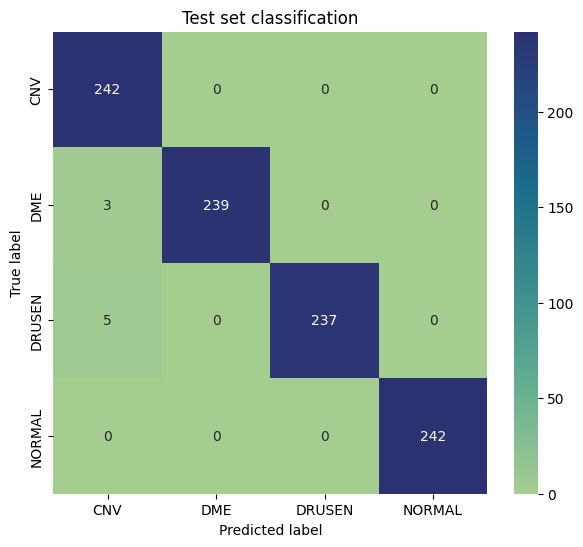

In [14]:
cm = confusion_matrix(all_labels, all_predictions)

class_names = test_dataset.classes

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="crest",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Test set classification")
plt.show()

In [15]:
# performance on validation set
model.eval() # evaluate mode on, must turn off for training

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(val_loader)
test_accuracy = 100*correct / total
# model.train()
print('Validation loss =', avg_test_loss)
print('Validation accuracy =',test_accuracy)

Validation loss = 0.03175724044443973
Validation accuracy = 96.875


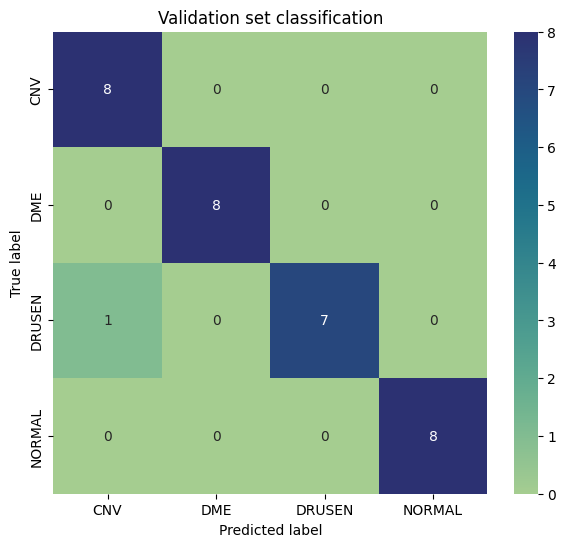

In [16]:
cm = confusion_matrix(all_labels, all_predictions)

class_names = val_dataset.classes

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="crest",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation set classification")
plt.show()

In [17]:
# feature extraction for SVM and KNN
import numpy as np
features = []
labels = []

model.eval()

with torch.no_grad():
    for inputs, y in train_loader:
        inputs = inputs.to(device)

        feats = model.extract_features(inputs)   # (B, 256)

        features.append(feats.cpu().numpy())
        labels.append(y.numpy())

X_train = np.vstack(features)
y_train = np.concatenate(labels)
print(X_train.shape)
print(y_train.shape)

(83484, 256)
(83484,)


In [18]:
# get feature vectors for test set
features = []
labels = []

model.eval()

with torch.no_grad():
    for inputs, y in test_loader:
        inputs = inputs.to(device)

        feats = model.extract_features(inputs)   # (B, 256)

        features.append(feats.cpu().numpy())
        labels.append(y.numpy())

X_test = np.vstack(features)
y_test = np.concatenate(labels)

print(X_test.shape)
print(y_test.shape)

# get feature vectors for validation set
features = []
labels = []

model.eval()

with torch.no_grad():
    for inputs, y in val_loader:
        inputs = inputs.to(device)

        feats = model.extract_features(inputs)   # (B, 256)

        features.append(feats.cpu().numpy())
        labels.append(y.numpy())

X_val = np.vstack(features)
y_val = np.concatenate(labels)
print(X_val.shape)
print(y_val.shape)

(968, 256)
(968,)
(32, 256)
(32,)


In [19]:
scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(X_train)
X_test_scaled = scaler_ml.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (83484, 256)
X_test_scaled shape: (968, 256)


In [20]:
# SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy: ", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report: ")
print(classification_report(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy:  0.9958677685950413

SVM Classification Report: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       242
           1       1.00      0.99      1.00       242
           2       1.00      0.99      1.00       242
           3       1.00      1.00      1.00       242

    accuracy                           1.00       968
   macro avg       1.00      1.00      1.00       968
weighted avg       1.00      1.00      1.00       968


SVM Classification Report:
[[242   0   0   0]
 [  2 240   0   0]
 [  2   0 240   0]
 [  0   0   0 242]]


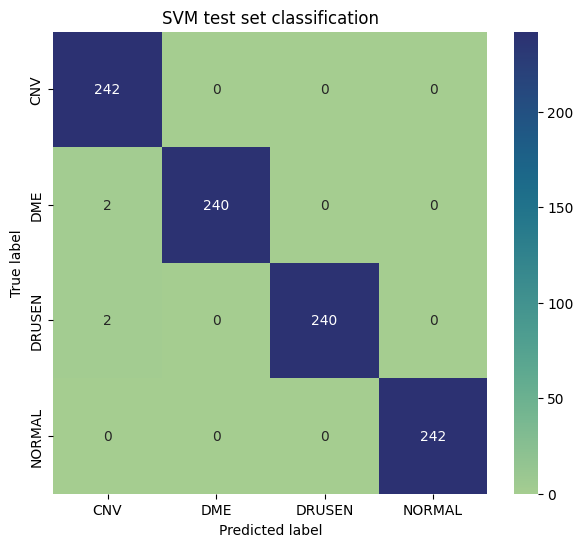

In [23]:
cm = confusion_matrix(y_test, y_pred_svm)

class_names = test_dataset.classes

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="crest",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("SVM test set classification")
plt.show()

In [24]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5, p=2)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy: ", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report: ")
print(classification_report(y_test, y_pred_knn))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy:  0.9927685950413223

KNN Classification Report: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       242
           1       1.00      0.97      0.99       242
           2       1.00      1.00      1.00       242
           3       0.99      1.00      1.00       242

    accuracy                           0.99       968
   macro avg       0.99      0.99      0.99       968
weighted avg       0.99      0.99      0.99       968


KNN Confusion Matrix:
[[242   0   0   0]
 [  5 235   0   2]
 [  0   0 242   0]
 [  0   0   0 242]]


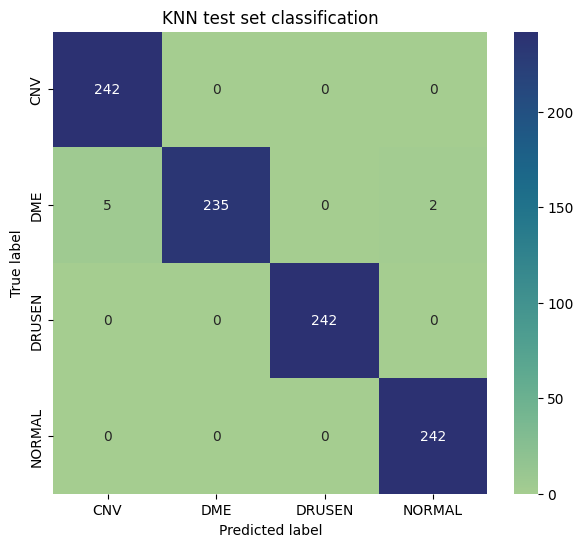

In [27]:
cm = confusion_matrix(y_test, y_pred_knn)

class_names = test_dataset.classes

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="crest",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("KNN test set classification")
plt.show()